In [2]:
import torch
from torch import nn

In [5]:
import requests
import zipfile
from pathlib import Path
data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"
if image_path.is_dir():
    print(f"{image_path} already exists")
else :
    print("Downloading images")
    image_path.mkdir(parents=True,exist_ok=True)


In [7]:
with open (data_path/ "pizza_steak_sushi.zip","wb") as f:
    request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    f.write(request.content)
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
    zip_ref.extractall(image_path)

In [8]:
import os
def walk_through_dir(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"{len(dirnames)},directories {len(filenames)}  image: {dirpath}")
walk_through_dir(image_path)

2,directories 0  image: data\pizza_steak_sushi
3,directories 0  image: data\pizza_steak_sushi\test
0,directories 25  image: data\pizza_steak_sushi\test\pizza
0,directories 19  image: data\pizza_steak_sushi\test\steak
0,directories 31  image: data\pizza_steak_sushi\test\sushi
3,directories 0  image: data\pizza_steak_sushi\train
0,directories 78  image: data\pizza_steak_sushi\train\pizza
0,directories 75  image: data\pizza_steak_sushi\train\steak
0,directories 72  image: data\pizza_steak_sushi\train\sushi


In [9]:
train_dir=image_path/"train"
test_dir=image_path/"test"

In [ ]:
import random
from PIL import Image
random.seed(42)
image_path_list=list(image_path.glob("*/*/*.jpg"))
image_path_list

data\pizza_steak_sushi\train\steak\421476.jpg
data\pizza_steak_sushi\train\steak\421476.jpg
Image class steak
Image height 512
Image width 512


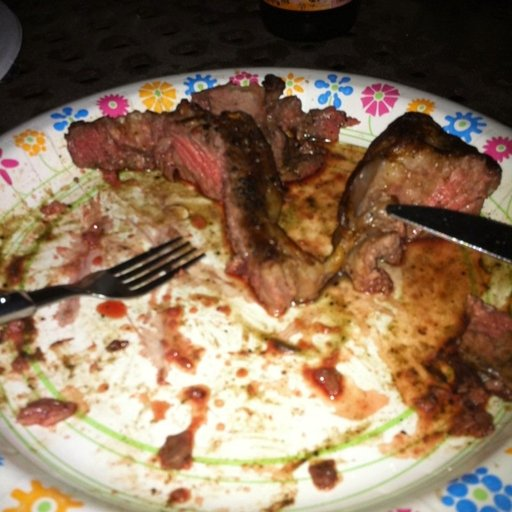

In [22]:
random_image_path=random.choice(image_path_list)
print(random_image_path)
image_class=random_image_path.parent.stem
img=Image.open(random_image_path)
print(random_image_path)
print(f"Image class {image_class}")
print(f"Image height {img.height}")
print(f"Image width {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

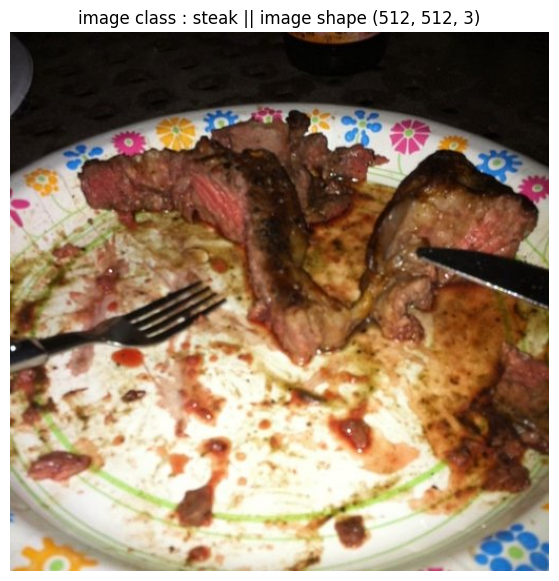

In [25]:
import numpy as np
import matplotlib.pyplot as plt
img_as_array=np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"image class : {image_class} || image shape { img_as_array.shape}")
plt.axis(False)

In [ ]:
img_as_array

In [42]:
import torch 
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

data_transform=transforms.Compose([
    transforms.Resize(size=(64,64)), # we can give it to 224 224 too
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [43]:
data_transform(img).shape

torch.Size([3, 64, 64])

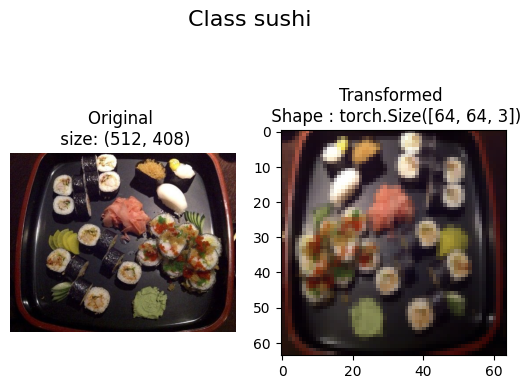

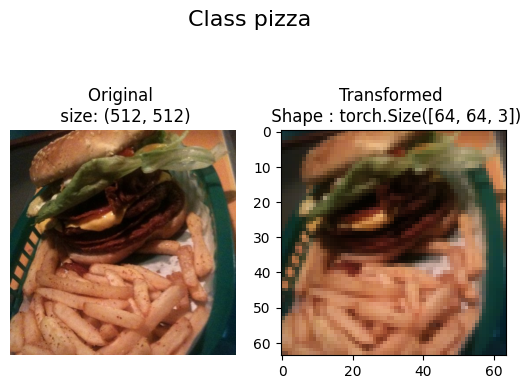

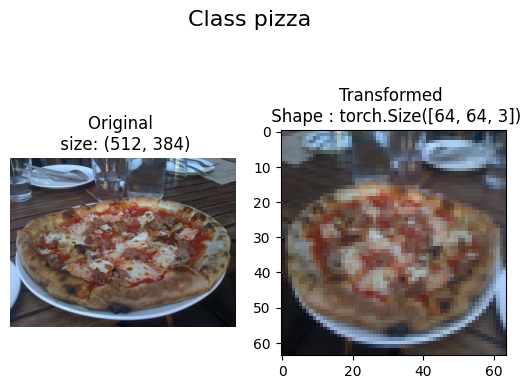

In [44]:
def plot_transformed_images(image_paths,transform,n=3,seed=42):
    if seed:
        random.seed(seed)
    random_image_paths=random.sample(image_paths,k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig,ax=plt.subplots(nrows=1,ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original \n size: {f.size}")
            ax[0].axis(False)
            transformed_image=transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed \n Shape : {transformed_image.shape}")

            fig.suptitle(f"Class {image_path.parent.stem}",fontsize=16)
plot_transformed_images(image_paths=image_path_list,transform=data_transform,n=3,seed=42)

In [46]:
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,transform=data_transform,
                               target_transform=None) #transform for target
test_data=datasets.ImageFolder(root=test_dir,transform=data_transform,
                               target_transform=None) #transform for target
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
class_names=train_data.classes
class_names